<a href="https://colab.research.google.com/github/haujla2391/CSCI-4170/blob/main/CSCI4170_hw5_task2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task 2

In [19]:
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import kagglehub
from torchvision.datasets import ImageFolder
from torchvision.transforms import transforms
from torch.utils.data import Dataset,DataLoader

In [20]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_device('cpu')

### Same dataset as part 1

In [21]:
path = kagglehub.dataset_download("gpiosenka/cards-image-datasetclassification")

df = pd.read_csv(path+"/cards.csv")
classes = df['labels'].unique()

Using Colab cache for faster access to the 'cards-image-datasetclassification' dataset.


In [22]:
transform_data = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
])

train_dataset = ImageFolder(path+"/train", transform_data)
valid_dataset = ImageFolder(path+"/valid", transform_data)
test_dataset = ImageFolder(path+"/test", transform_data)

### Hyperparameters

In [23]:
batch_size = 32
num_epochs = 50
lr = 0.00001
weight_decay = 0.0001

In [24]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Variational Autoencoder (Pytorch)

In [25]:
class Encoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1),
        nn.ReLU(),

        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1),
        nn.ReLU()
    )
    self.fc_mu = nn.Linear(256*(14*14), 128)
    self.fc_var = nn.Linear(256*(14*14), 128)

  def forward(self, x):
    x = self.conv(x)
    x = x.view(x.size(0), -1)
    mu  = self.fc_mu(x)
    log_var = self.fc_var(x)
    return mu, log_var

In [26]:
class Decoder(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(128, 256*(14*14))
    self.deconv = nn.Sequential(
      nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1),
      nn.ReLU(),

      nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1),
      nn.ReLU(),

      nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1),
      nn.ReLU(),

      nn.ConvTranspose2d(in_channels=32, out_channels=3, kernel_size=4, stride=2, padding=1),
      nn.Sigmoid()
    )

  def forward(self, z):
    x = self.fc1(z)
    x = x.view(x.size(0), 256, 14, 14)
    return self.deconv(x)

In [27]:
class VAE(nn.Module):
  def __init__(self):
    super().__init__()
    self.encoder = Encoder()
    self.decoder = Decoder()

  def reparametrize(self, mu, log_var):
    std = torch.exp(0.5 * log_var)
    eps = torch.randn_like(std)
    return mu + eps * std

  def forward(self, x):
    mu, log_var = self.encoder(x)
    z = self.reparametrize(mu, log_var)
    recon = self.decoder(z)
    return recon, mu, log_var

### Loss and optim

In [28]:
def vae_loss(recon, x, mu, log_var):
  recon_loss = nn.functional.binary_cross_entropy(recon, x, reduction="sum")
  kl_div = -0.5 * torch.sum(1 + log_var - mu**2 - torch.exp(log_var))
  return recon_loss + kl_div

In [29]:
model = VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

### Train phase

In [30]:
def train(dataloader, model, optimizer):
  model.train()
  total_loss = 0
  for X, _ in dataloader:
    X = X.to(device)
    recon, mu, log_var = model(X)
    loss = vae_loss(recon, X, mu, log_var)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  return total_loss / len(dataloader)

In [31]:
def val(dataloader, model):
  model.eval()
  total_loss = 0
  with torch.no_grad():
    for X, _ in dataloader:
      X = X.to(device)

      recon, mu, log_var = model(X)
      loss = vae_loss(recon, X, mu, log_var)
      total_loss += loss.item()
  return total_loss / len(dataloader)

In [32]:
train_losses, val_losses = [], []
for epoch in range(num_epochs):
  print("Epoch: ", epoch+1)

  train_loss = train(train_loader, model, optimizer)
  val_loss = val(val_loader, model)

  train_losses.append(train_loss)
  val_losses.append(val_loss)

Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
Epoch:  5
Epoch:  6
Epoch:  7
Epoch:  8
Epoch:  9
Epoch:  10
Epoch:  11
Epoch:  12
Epoch:  13
Epoch:  14
Epoch:  15
Epoch:  16
Epoch:  17
Epoch:  18
Epoch:  19
Epoch:  20
Epoch:  21
Epoch:  22
Epoch:  23
Epoch:  24
Epoch:  25
Epoch:  26
Epoch:  27
Epoch:  28
Epoch:  29
Epoch:  30
Epoch:  31
Epoch:  32
Epoch:  33
Epoch:  34
Epoch:  35
Epoch:  36
Epoch:  37
Epoch:  38
Epoch:  39
Epoch:  40
Epoch:  41
Epoch:  42
Epoch:  43
Epoch:  44
Epoch:  45
Epoch:  46
Epoch:  47
Epoch:  48
Epoch:  49
Epoch:  50


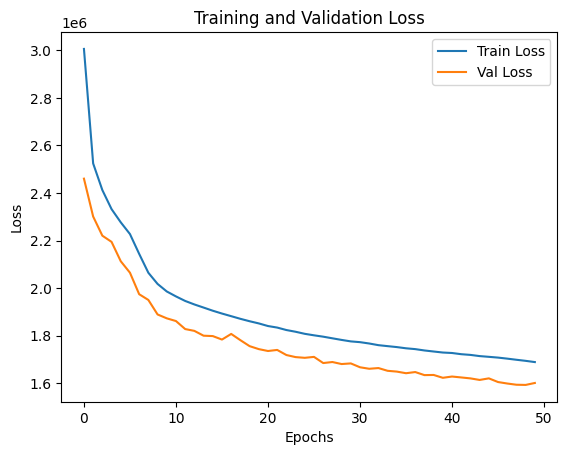

In [33]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

### Test phase

In [34]:
avgloss_vae = val(test_loader, model)
print("Average Loss: ", avgloss_vae)

Average Loss:  1578293.1805555555


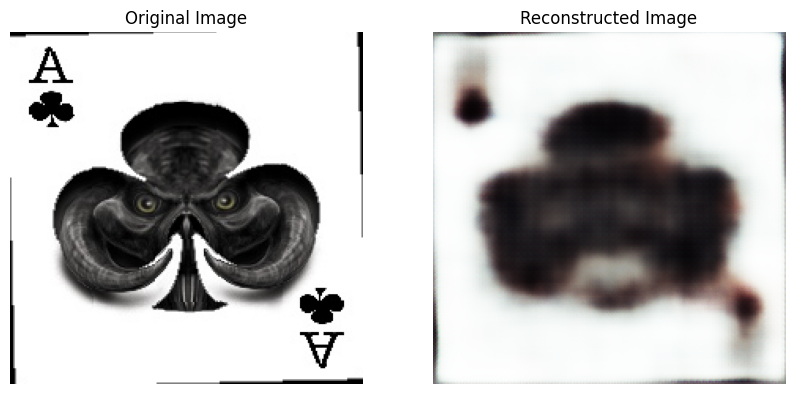

In [35]:
import matplotlib.pyplot as plt
import numpy as np

model.eval()
with torch.no_grad():
  # Get a batch of images from the test loader
  dataiter = iter(test_loader)
  images, _ = next(dataiter)
  images = images.to(device)

  # Reconstruct the images using the VAE
  reconstructed_images, _, _ = model(images)

  # Take the first image from the batch for comparison
  original_image = images[0].cpu().permute(1, 2, 0).numpy() # (C, H, W) -> (H, W, C)
  reconstructed_image = reconstructed_images[0].cpu().permute(1, 2, 0).numpy() # (C, H, W) -> (H, W, C)

  # Plotting
  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.imshow(original_image)
  plt.title('Original Image')
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(reconstructed_image)
  plt.title('Reconstructed Image')
  plt.axis('off')

  plt.show()

As we can see, the VAE did a decent job in reconstructing the image, it is very blurry compared to the original but I think that with more epochs, the model could do a better job.

# Generative Adversarial Network (Pytorch)

In [ ]:
transform_data = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

train_dataset = ImageFolder(path+"/train", transform_data)
valid_dataset = ImageFolder(path+"/valid", transform_data)
test_dataset = ImageFolder(path+"/test", transform_data)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(valid_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
class Generator(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc1 = nn.Linear(128, 256*(14*14))
    self.deconv = nn.Sequential(
      nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1),
      nn.BatchNorm2d(128),
      nn.ReLU(),

      nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1),
      nn.BatchNorm2d(64),
      nn.ReLU(),

      nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, stride=2, padding=1),
      nn.BatchNorm2d(32),
      nn.ReLU(),

      nn.ConvTranspose2d(in_channels=32, out_channels=3, kernel_size=4, stride=2, padding=1),
      nn.Tanh()
    )

  def forward(self, x):
    x = self.fc1(x)
    x = x.view(x.size(0), 256, 14, 14)
    return self.deconv(x)

In [ ]:
from torch.nn.modules.activation import Sigmoid
class Discriminator(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=32, kernel_size=4, stride=2, padding=1),
        nn.LeakyReLU(0.2),

        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(64),
        nn.LeakyReLU(0.2),

        nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2),

        nn.Conv2d(in_channels=128, out_channels=256, kernel_size=4, stride=2, padding=1),
        nn.BatchNorm2d(256),
        nn.LeakyReLU(0.2)
    )
    self.fc = nn.Sequential(
        nn.Linear(256*(14*14), 1),
        nn.Sigmoid()
    )

  def forward(self, x):
    x = self.conv(x)
    x = x.view(x.size(0), -1)
    return self.fc(x)

### Loss and optimizer

In [ ]:
gen  = Generator().to(device)
disc = Discriminator().to(device)

criterion = nn.BCELoss()
optim_gen = torch.optim.Adam(gen.parameters(), lr=lr)
optim_disc = torch.optim.Adam(disc.parameters(), lr=lr)

### Train phase

In [ ]:
def train_gan(dataloader, gen, disc, opt_gen, opt_disc):
  gen.train()
  disc.train()
  total_g_loss = 0
  total_d_loss = 0

  for X, _ in dataloader:
    X = X.to(device)

    batch_size_curr = X.size(0)

    real_labels = torch.ones(batch_size_curr, 1).to(device)
    fake_labels = torch.zeros(batch_size_curr, 1).to(device)

    # Disc
    z = torch.randn(batch_size_curr, 128).to(device)
    fake_im = gen(z)

    real_loss = criterion(disc(X), real_labels)
    fake_loss = criterion(disc(fake_im.detach()), fake_labels)
    disc_loss = real_loss + fake_loss

    optim_disc.zero_grad()
    disc_loss.backward()
    optim_disc.step()

    # Gen
    z = torch.randn(batch_size_curr, 128).to(device)
    fake_im = gen(z)

    gen_loss = criterion(disc(fake_im), real_labels)
    optim_gen.zero_grad()
    gen_loss.backward()
    optim_gen.step()

    total_g_loss += gen_loss.item()
    total_d_loss += disc_loss.item()

  return total_g_loss / len(dataloader), total_d_loss / len(dataloader)

In [ ]:
def val_gan(dataloader, gen, disc):
  gen.eval()
  disc.eval()
  total_g_loss = 0
  total_d_loss = 0

  with torch.no_grad():
    for X, _ in dataloader:
      X = X.to(device)

      batch_size_curr = X.size(0)

      real_labels = torch.ones(batch_size_curr, 1).to(device)
      fake_labels = torch.zeros(batch_size_curr, 1).to(device)

      # Disc
      z = torch.randn(batch_size_curr, 128).to(device)
      fake_im = gen(z)

      real_loss = criterion(disc(X), real_labels)
      fake_loss = criterion(disc(fake_im), fake_labels)
      disc_loss = real_loss + fake_loss

      # Gen
      z = torch.randn(batch_size_curr, 128).to(device)
      fake_im = gen(z)

      gen_loss = criterion(disc(fake_im), real_labels)

      total_g_loss += gen_loss.item()
      total_d_loss += disc_loss.item()

  return total_g_loss / len(dataloader), total_d_loss / len(dataloader)

In [ ]:
train_losses_g, val_losses_g = [], []
train_losses_d, val_losses_d = [], []
for epoch in range(num_epochs):
    print("Epoch: ", epoch+1)
    train_g_loss, train_d_loss = train_gan(train_loader, gen, disc, optim_gen, optim_disc)
    val_g_loss, val_d_loss = val_gan(val_loader, gen, disc)

    train_losses_g.append(train_g_loss)
    val_losses_g.append(val_g_loss)
    train_losses_d.append(train_d_loss)
    val_losses_d.append(val_d_loss)

Epoch:  1
Epoch:  2
Epoch:  3
Epoch:  4
Epoch:  5
Epoch:  6
Epoch:  7
Epoch:  8
Epoch:  9
Epoch:  10
Epoch:  11
Epoch:  12
Epoch:  13
Epoch:  14
Epoch:  15
Epoch:  16
Epoch:  17
Epoch:  18
Epoch:  19
Epoch:  20
Epoch:  21
Epoch:  22
Epoch:  23
Epoch:  24
Epoch:  25
Epoch:  26
Epoch:  27
Epoch:  28
Epoch:  29
Epoch:  30
Epoch:  31
Epoch:  32
Epoch:  33
Epoch:  34
Epoch:  35
Epoch:  36
Epoch:  37
Epoch:  38
Epoch:  39
Epoch:  40
Epoch:  41
Epoch:  42
Epoch:  43
Epoch:  44
Epoch:  45
Epoch:  46
Epoch:  47
Epoch:  48
Epoch:  49
Epoch:  50


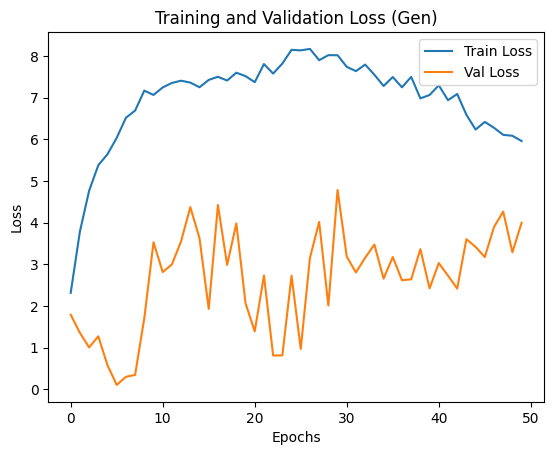

In [ ]:
plt.plot(train_losses_g, label='Train Loss')
plt.plot(val_losses_g, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss (Gen)')
plt.show()

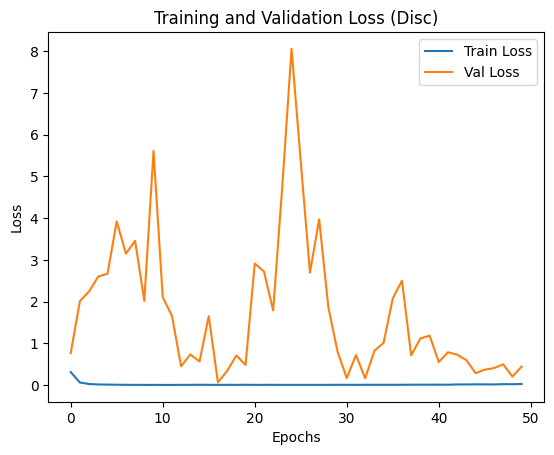

In [ ]:
plt.plot(train_losses_d, label='Train Loss')
plt.plot(val_losses_d, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss (Disc)')
plt.show()

### Test phase

In [ ]:
test_g_loss, test_d_loss = val_gan(test_loader, gen, disc)

print(f"Test G: {test_g_loss:.4f}, Test D: {test_d_loss:.4f}")

Test G: 3.9129, Test D: 0.4128


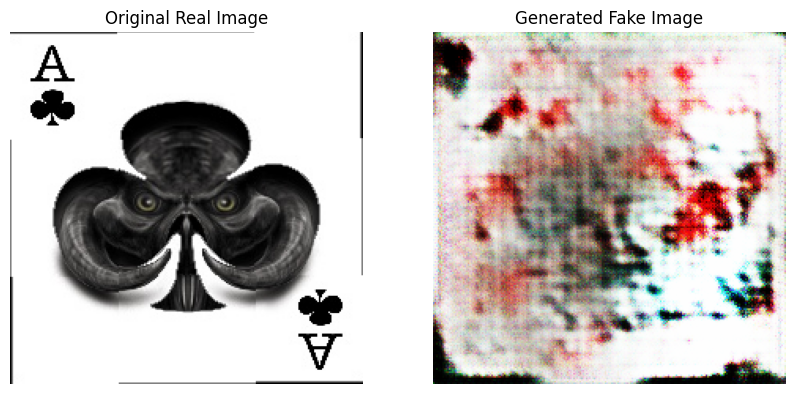

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

gen.eval()
with torch.no_grad():
  # Get a batch of real images from the test loader
  dataiter = iter(test_loader)
  real_images, _ = next(dataiter)
  real_images = real_images.to(device)

  # Generate a fake image using the generator
  z = torch.randn(1, 128).to(device) # Generate one random noise vector
  fake_image = gen(z).cpu().squeeze(0) # Generate fake image and move to CPU, remove batch dimension

  # Take the first real image from the batch for comparison
  original_image = real_images[0].cpu() # Get the first real image and move to CPU

  # Unnormalize the images for display
  # Normalization applied was: transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
  # Unnormalization: image = image * std + mean
  original_image = original_image * 0.5 + 0.5
  fake_image = fake_image * 0.5 + 0.5

  # Convert to numpy and permute dimensions for matplotlib (C, H, W) -> (H, W, C)
  original_image = original_image.permute(1, 2, 0).numpy()
  fake_image = fake_image.permute(1, 2, 0).numpy()

  # Plotting
  plt.figure(figsize=(10, 5))

  plt.subplot(1, 2, 1)
  plt.imshow(original_image)
  plt.title('Original Real Image')
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(fake_image)
  plt.title('Generated Fake Image')
  plt.axis('off')

  plt.show()

The GAN tries to generate a new image based on the dataset of images and it seems to get the pattern generally right. There is a card like rectangle of white with some colors in the middle. With some more training, it could be better at being more realistic.